**Step 1: Upload Data & Setup Environment**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving exams.csv to exams.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets (Replace filenames if yours are named differently)
# Assuming you have uploaded 'exams.csv' and 'exam_sessions.csv' to Colab
exams = pd.read_csv('/content/drive/MyDrive/Work File/DATA ANALYST/student-data-bigquery/exams.csv')
sessions = pd.read_csv('/content/drive/MyDrive/Work File/DATA ANALYST/student-data-bigquery/exam_sessions.csv')

# 2. Data Cleaning for SQL
# Ensure timestamps are actual datetime objects for sorting
sessions['user_exam_starts_at'] = pd.to_datetime(sessions['user_exam_starts_at'])

# 3. Create an in-memory SQL database
conn = sqlite3.connect(':memory:')

# 4. Write dataframes to SQL tables
exams.to_sql('exams', conn, index=False, if_exists='replace')
sessions.to_sql('exam_sessions', conn, index=False, if_exists='replace')

print("Database created and tables loaded successfully!")

Database created and tables loaded successfully!


**Step 2: Solve Questions 1 - 4 (SQL Queries)**

In [ ]:
# QUESTION 1: Actual Mark Calculation

q1_query = """
SELECT
    s.user_id,
    e.exam_name,
    s.session_id,
    (s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking) AS actual_mark
FROM exam_sessions s
JOIN exams e ON s.exam_id = e.exam_id;
"""
df_q1 = pd.read_sql(q1_query, conn)
print("--- Question 1: Sample Output ---")
print(df_q1.head())
print("\n")

--- Question 1: Sample Output ---
                    user_id                                exam_name  \
0  623ad09bfb492fa5df2dc9d4   Class 10 - Monthly MCQ Exam - February   
1  623a4e7cfb492fa5df1515a9   Class 10 - Monthly MCQ Exam - February   
2  623ad09bfb492fa5df2dc9d4      Class 10 - Monthly MCQ Exam - March   
3  623ad09bfb492fa5df2dc9d4  Class 10 - Weekly MCQ Exam - February 1   
4  623a4e7cfb492fa5df1515a9  Class 10 - Weekly MCQ Exam - February 2   

                 session_id  actual_mark  
0  67c56ad455f584a4862bff7c        27.50  
1  67cd98fb1ca1a4ada7cc41e5        16.25  
2  67ee631c3db3b091e19c764f        26.25  
3  67b0800e64933092bedbb048        19.00  
4  67bdcde591f4ff5af1c21924         3.75  




In [ ]:
# QUESTION 2: Pass / Fail Classification

q2_query = """
SELECT
    s.user_id AS auth_user_id,
    e.exam_name,
    (s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking) AS actual_mark,
    e.pass_mark,
    CASE
        WHEN ((s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking)) >= e.pass_mark
        THEN 'Pass'
        ELSE 'Fail'
    END AS result_status
FROM exam_sessions s
JOIN exams e ON s.exam_id = e.exam_id;
"""
df_q2 = pd.read_sql(q2_query, conn)
print("--- Question 2: Sample Output ---")
print(df_q2.head())
print("\n")

--- Question 2: Sample Output ---
               auth_user_id                                exam_name  \
0  623ad09bfb492fa5df2dc9d4   Class 10 - Monthly MCQ Exam - February   
1  623a4e7cfb492fa5df1515a9   Class 10 - Monthly MCQ Exam - February   
2  623ad09bfb492fa5df2dc9d4      Class 10 - Monthly MCQ Exam - March   
3  623ad09bfb492fa5df2dc9d4  Class 10 - Weekly MCQ Exam - February 1   
4  623a4e7cfb492fa5df1515a9  Class 10 - Weekly MCQ Exam - February 2   

   actual_mark  pass_mark result_status  
0        27.50         12          Pass  
1        16.25         12          Pass  
2        26.25         12          Pass  
3        19.00         10          Pass  
4         3.75         12          Fail  




In [ ]:
# QUESTION 3: Top 5 Performers

q3_query = """
WITH RankedStudents AS (
    SELECT
        e.exam_name,
        s.user_id AS auth_user_id,
        (s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking) AS actual_mark,
        RANK() OVER (
            PARTITION BY e.exam_name
            ORDER BY ((s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking)) DESC
        ) as rank
    FROM exam_sessions s
    JOIN exams e ON s.exam_id = e.exam_id
)
SELECT *
FROM RankedStudents
WHERE rank <= 5;
"""
df_q3 = pd.read_sql(q3_query, conn)
print("--- Question 3: Sample Output ---")
print(df_q3.head(10)) # Showing top 10 rows
print("\n")


--- Question 3: Sample Output ---
                                exam_name              auth_user_id  \
0  Class 10 - Monthly MCQ Exam - February  623ad09bfb492fa5df2dc9d4   
1  Class 10 - Monthly MCQ Exam - February  623a318efb492fa5df0c24df   
2  Class 10 - Monthly MCQ Exam - February  623a3c91fb492fa5df0fe5fc   
3  Class 10 - Monthly MCQ Exam - February  623ad09bfb492fa5df2dc9d4   
4  Class 10 - Monthly MCQ Exam - February  623a8a95fb492fa5df224248   
5     Class 10 - Monthly MCQ Exam - March  623a318efb492fa5df0c24df   
6     Class 10 - Monthly MCQ Exam - March  623acd24fb492fa5df2d4517   
7     Class 10 - Monthly MCQ Exam - March  623a3c91fb492fa5df0fe5fc   
8     Class 10 - Monthly MCQ Exam - March  623a7385fb492fa5df1dc1c8   
9     Class 10 - Monthly MCQ Exam - March  623abbadfb492fa5df2a98e7   

   actual_mark  rank  
0        30.00     1  
1        30.00     1  
2        30.00     1  
3        28.75     4  
4        28.75     4  
5        30.00     1  
6        28.75     2  


In [ ]:
# QUESTION 4: Performance Trend (Using LAG)

q4_query = """
WITH CalculatedMarks AS (
    SELECT
        s.user_id AS auth_user_id,
        e.exam_name,
        s.user_exam_starts_at,
        (s.total_correct_answers * e.each_ques_mark) - (s.total_false_answers * e.per_ques_negative_marking) AS actual_mark
    FROM exam_sessions s
    JOIN exams e ON s.exam_id = e.exam_id
),
LaggedMarks AS (
    SELECT
        auth_user_id,
        exam_name,
        user_exam_starts_at,
        actual_mark,
        LAG(actual_mark) OVER (
            PARTITION BY auth_user_id
            ORDER BY user_exam_starts_at
        ) AS previous_actual_mark
    FROM CalculatedMarks
)
SELECT
    auth_user_id,
    exam_name,
    user_exam_starts_at,
    actual_mark,
    previous_actual_mark,
    CASE
        WHEN previous_actual_mark IS NULL THEN NULL
        WHEN actual_mark > previous_actual_mark THEN 'Improved'
        WHEN actual_mark < previous_actual_mark THEN 'Declined'
        ELSE 'Same'
    END AS performance_trend
FROM LaggedMarks
ORDER BY auth_user_id, user_exam_starts_at;
"""
df_q4 = pd.read_sql(q4_query, conn)
print("--- Question 4: Sample Output ---")
print(df_q4.head(10))

--- Question 4: Sample Output ---
               auth_user_id                                exam_name  \
0  623a318cfb492fa5df0c2456                    সাপ্তাহিক পরীক্ষা - ১   
1  623a318cfb492fa5df0c2456                     Monthly Exam 1 (MCQ)   
2  623a318cfb492fa5df0c2456  Class 10 - Weekly MCQ Exam - February 1   
3  623a318cfb492fa5df0c2456                     Monthly Exam 1 (MCQ)   
4  623a318cfb492fa5df0c2456  Class 10 - Weekly MCQ Exam - February 2   
5  623a318cfb492fa5df0c2456  Class 10 - Weekly MCQ Exam - February 3   
6  623a318cfb492fa5df0c2456   Class 10 - Monthly MCQ Exam - February   
7  623a318cfb492fa5df0c2456     Class 10 - Weekly MCQ Exam - March 1   
8  623a318cfb492fa5df0c2456     Class 10 - Weekly MCQ Exam - March 2   
9  623a318cfb492fa5df0c2456     Class 10 - Weekly MCQ Exam - April 1   

                user_exam_starts_at  actual_mark  previous_actual_mark  \
0  2025-01-25 12:30:59.666000+00:00        15.00                   NaN   
1  2025-02-02 10:10:20.02

**Question 5 (Visualizations)**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# 1. Fix datetime parsing (IMPORTANT)

df_q4['user_exam_starts_at'] = pd.to_datetime(
    df_q4['user_exam_starts_at'],
    format='mixed',
    utc=True,
    errors='coerce'
)

# Drop rows where datetime could not be parsed (optional but recommended)
df_q4 = df_q4.dropna(subset=['user_exam_starts_at'])

# Create date-only column
df_q4['exam_date'] = df_q4['user_exam_starts_at'].dt.date


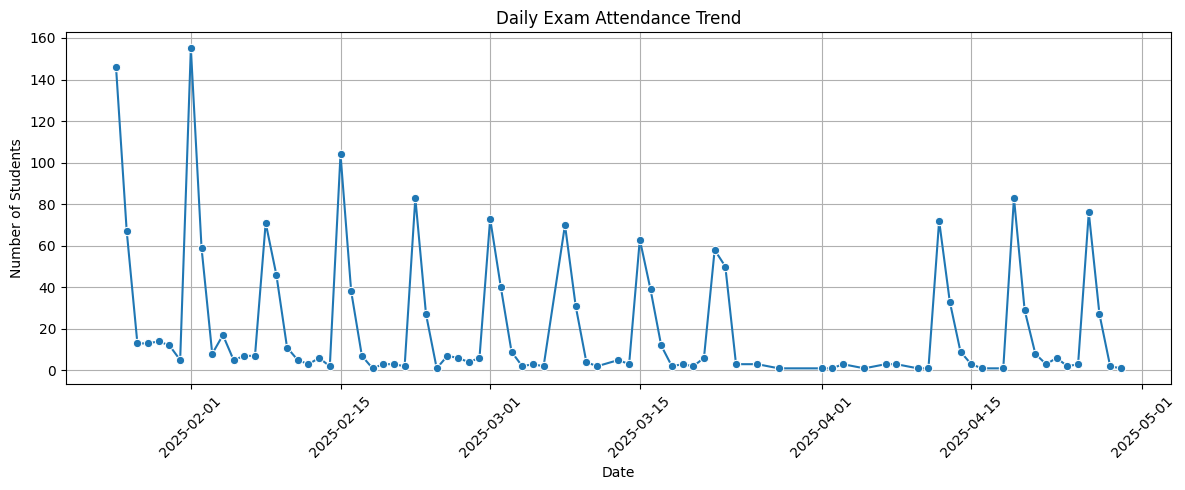

In [ ]:
# 5.1 Day-wise Exam Attendance Trend

plt.figure(figsize=(12, 5))

attendance = df_q4.groupby('exam_date').size().reset_index(name='count')

sns.lineplot(
    data=attendance,
    x='exam_date',
    y='count',
    marker='o'
)

plt.title('Daily Exam Attendance Trend')
plt.xlabel('Date')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3059339513.py:21: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-30593395

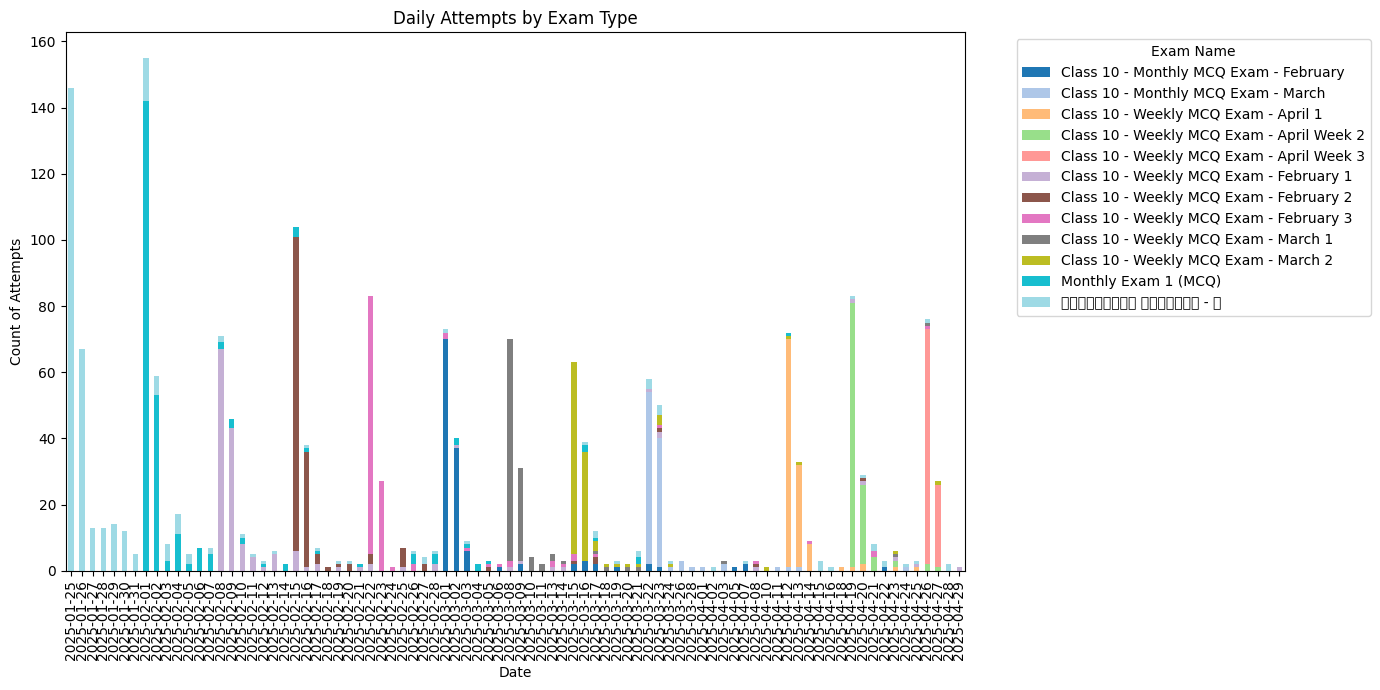

In [ ]:
# 5.2 Stacked Bar Chart: Daily Attempts by Exam

daily_exam_counts = (
    df_q4
    .groupby(['exam_date', 'exam_name'])
    .size()
    .unstack(fill_value=0)
)

daily_exam_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.title('Daily Attempts by Exam Type')
plt.xlabel('Date')
plt.ylabel('Count of Attempts')
plt.legend(title='Exam Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

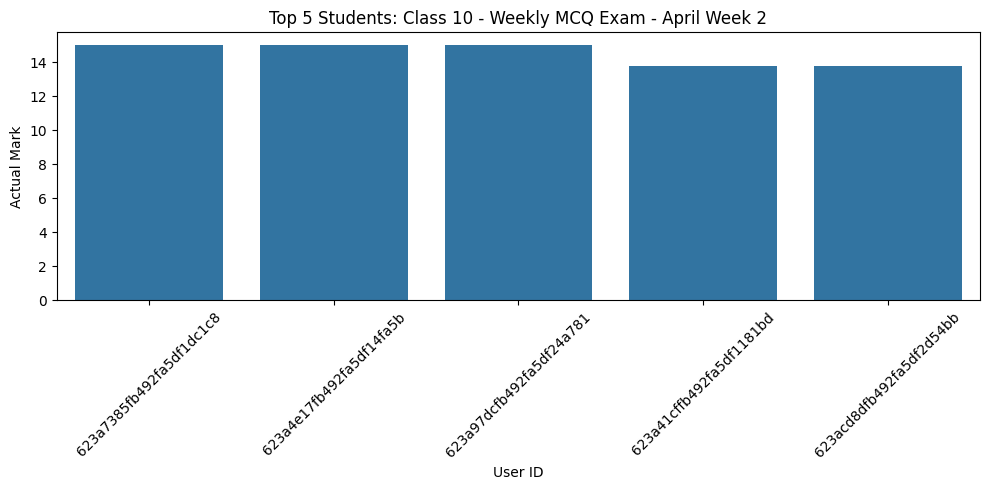

In [ ]:
# 5.3 Top 5 Students in the Most Popular Exam

popular_exam = df_q3['exam_name'].value_counts().idxmax()

top_students = (
    df_q3[df_q3['exam_name'] == popular_exam]
    .sort_values('rank')
    .head(5)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_students,
    x='auth_user_id',
    y='actual_mark'
)

plt.title(f'Top 5 Students: {popular_exam}')
plt.ylabel('Actual Mark')
plt.xlabel('User ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

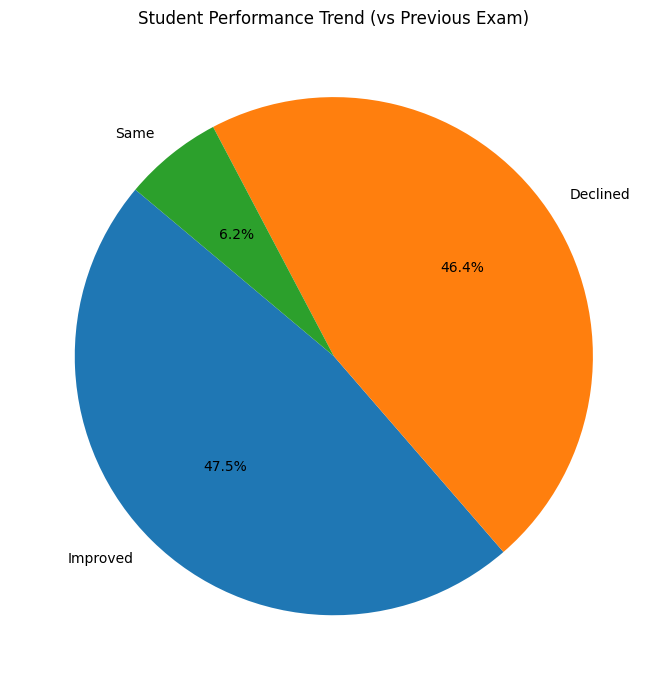

In [ ]:

# 5.4 Performance Trend Categories

trend_counts = df_q4['performance_trend'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    trend_counts,
    labels=trend_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Student Performance Trend (vs Previous Exam)')
plt.tight_layout()
plt.show()

**Optional Questions Logic**

In [ ]:
# Filter for 2nd attempts where improvement happened
second_attempts = df_q4[df_q4['previous_actual_mark'].notnull()].copy()

# Calculate improvement amount
second_attempts['improvement_score'] = second_attempts['actual_mark'] - second_attempts['previous_actual_mark']

# Find max
best_improver = second_attempts.loc[second_attempts['improvement_score'].idxmax()]
print(f"Top Improver: User {best_improver['auth_user_id']} improved by {best_improver['improvement_score']} marks.")

Top Improver: User 623a9117fb492fa5df237351 improved by 28.75 marks.


In [ ]:
declines = df_q4[df_q4['performance_trend'] == 'Declined']
decline_counts = declines['exam_name'].value_counts()
print("Exam with most declines:", decline_counts.idxmax())

Exam with most declines: Class 10 - Weekly MCQ Exam - February 3


In [ ]:
# Create numeric pass status (1 for Pass, 0 for Fail)
df_q2_w_date = df_q2.copy()
# Merge date back in from sessions dataframe
df_q2_w_date = df_q2_w_date.merge(sessions[['user_id', 'user_exam_starts_at']], left_on='auth_user_id', right_on='user_id')
df_q2_w_date['is_passed'] = df_q2_w_date['result_status'].apply(lambda x: 1 if x == 'Pass' else 0)
df_q2_w_date['date_ordinal'] = pd.to_datetime(df_q2_w_date['user_exam_starts_at']).map(pd.Timestamp.toordinal)

correlation = df_q2_w_date['date_ordinal'].corr(df_q2_w_date['is_passed'])
print(f"Correlation between Date and Pass Rate: {correlation:.4f}")

Correlation between Date and Pass Rate: -0.0375
